In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Импортируем необходимые модули:
# - train_test_split для разбиения данных на обучающую и тестовую выборки.
# - Метрики classification_report, confusion_matrix, accuracy_score для количественной оценки модели.
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Импортируем CN2Learner из Orange3 – алгоритм, реализующий правило-ориентированное обучение (CN2).
# Также импортируем классы для работы с данными Orange (Table, Domain, DiscreteVariable).
from Orange.classification import CN2Learner
from Orange.data import Table, Domain, DiscreteVariable

# 1. Загрузка данных
# Загружаем датасет "mushrooms.csv", который содержит данные о грибах.
# Целевая переменная 'class' обычно указывает, съедобен гриб или ядовит.
data = pd.read_csv("../data/mushrooms.csv")

# 2. Преобразование категориальных данных в тип 'category'
# Так как все признаки в датасете являются категориальными, приводим каждый столбец к типу category.
# Это необходимо для последующей обработки, кодирования и корректного создания домена для Orange.
for column in data.columns:
    data[column] = data[column].astype('category')

# Определяем признаки (X) и целевую переменную (y)
# X – все столбцы, кроме 'class', а y – непосредственно 'class'.
X = data.drop(columns=['class'])
y = data['class']

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)

In [2]:

print(data.head())

  class cap-shape cap-surface cap-color bruises odor gill-attachment gill-spacing gill-size  \
0     p         x           s         n       t    p               f            c         n   
1     e         x           s         y       t    a               f            c         b   
2     e         b           s         w       t    l               f            c         b   
3     p         x           y         w       t    p               f            c         n   
4     e         x           s         g       f    n               f            w         b   

  gill-color stalk-shape stalk-root stalk-surface-above-ring stalk-surface-below-ring  \
0          k           e          e                        s                        s   
1          k           e          c                        s                        s   
2          n           e          c                        s                        s   
3          n           e          e                        s             

In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   class                     8124 non-null   category
 1   cap-shape                 8124 non-null   category
 2   cap-surface               8124 non-null   category
 3   cap-color                 8124 non-null   category
 4   bruises                   8124 non-null   category
 5   odor                      8124 non-null   category
 6   gill-attachment           8124 non-null   category
 7   gill-spacing              8124 non-null   category
 8   gill-size                 8124 non-null   category
 9   gill-color                8124 non-null   category
 10  stalk-shape               8124 non-null   category
 11  stalk-root                8124 non-null   category
 12  stalk-surface-above-ring  8124 non-null   category
 13  stalk-surface-below-ring  8124 non-null   catego

In [ ]:
print(data.describe())



In [4]:

# Разделение данных на обучающую и тестовую выборки.
# Используем stratify=y, чтобы пропорции классов остались примерно одинаковыми в обоих наборах.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Создание домена Orange3
# Для работы с алгоритмами Orange необходимо создать Domain – описание набора признаков и целевой переменной.
# Каждый признак описывается как DiscreteVariable с указанием возможных значений (из категорий столбца).
feature_vars = [DiscreteVariable(name, values=list(data[name].cat.categories)) for name in X.columns]
# Целевая переменная 'class' также определяется как DiscreteVariable.
class_var = DiscreteVariable('class', values=list(y.cat.categories))
# Объединяем признаки и целевую переменную в один домен.
domain = Domain(feature_vars, class_var)

# 4. Преобразование категориальных данных в числовые коды
# Для обучения модели необходимо преобразовать категориальные данные в числовой формат.
# Для каждого столбца обучающей и тестовой выборки получаем числовые коды (cat.codes).
X_train_enc = np.column_stack([X_train[col].cat.codes for col in X_train.columns])
y_train_enc = y_train.cat.codes.to_numpy().reshape(-1, 1)

X_test_enc = np.column_stack([X_test[col].cat.codes for col in X_test.columns])
y_test_enc = y_test.cat.codes.to_numpy().reshape(-1, 1)

# 5. Преобразование данных в формат Orange3 Table
# Объединяем преобразованные признаки и целевую переменную и создаем объекты Table для обучающей и тестовой выборок.
train_data = Table(domain, np.hstack((X_train_enc, y_train_enc)))
test_data = Table(domain, np.hstack((X_test_enc, y_test_enc)))

# 6. Обучение модели CN2
# Инициализируем CN2Learner – правило-ориентированный классификатор.
# Обучаем модель на обучающем наборе данных.
cn2 = CN2Learner()
model = cn2(train_data)

# 7. Предсказание на тестовой выборке
# Для каждого объекта из тестового набора получаем предсказание с помощью обученной модели.
# Результаты собираем в массив y_pred.
y_pred = np.array([model(x) for x in test_data])

       class cap-shape cap-surface cap-color bruises  odor gill-attachment gill-spacing gill-size  \
count   8124      8124        8124      8124    8124  8124            8124         8124      8124   
unique     2         6           4        10       2     9               2            2         2   
top        e         x           y         n       f     n               f            c         b   
freq    4208      3656        3244      2284    4748  3528            7914         6812      5612   

       gill-color stalk-shape stalk-root stalk-surface-above-ring stalk-surface-below-ring  \
count        8124        8124       8124                     8124                     8124   
unique         12           2          5                        4                        4   
top             b           t          b                        s                        s   
freq         1728        4608       3776                     5176                     4936   

       stalk-color-abov

In [5]:

# 8. Оценка результатов
# Выводим подробный отчет по классификации:
# - precision (точность) – доля верных положительных предсказаний среди всех положительных,
# - recall (полнота) – доля верных положительных предсказаний среди всех реальных положительных,
# - f1-score – гармоническое среднее между precision и recall.
print("\nОтчет по классификации:")
print(classification_report(y_test_enc, y_pred, digits=4))


Отчет по классификации:
              precision    recall  f1-score   support

           0     0.9992    0.9960    0.9976      1263
           1     0.9958    0.9991    0.9975      1175

    accuracy                         0.9975      2438
   macro avg     0.9975    0.9976    0.9975      2438
weighted avg     0.9975    0.9975    0.9975      2438



In [6]:

# Вычисляем и выводим общую точность модели (accuracy) – долю правильно классифицированных объектов.
accuracy = accuracy_score(y_test_enc, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9975


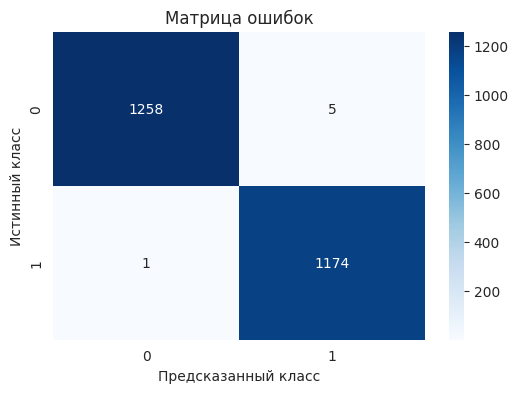

In [7]:

# 9. Визуализация результатов

## 9.1. Матрица ошибок
# Строим тепловую карту матрицы ошибок с помощью seaborn.
# Матрица ошибок показывает количество верных и ошибочных предсказаний для каждого класса.
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_enc, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Матрица ошибок")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

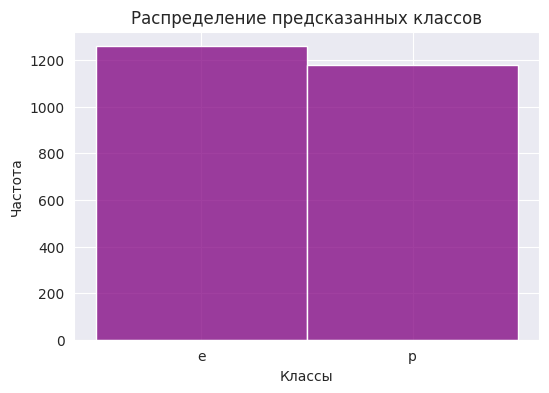

In [8]:

## 9.2. Гистограмма предсказанных классов
# Построение гистограммы позволяет увидеть распределение предсказанных классов.
# Это помогает оценить, как модель распределяет объекты между классами.
plt.figure(figsize=(6, 4))
sns.histplot(y_pred, bins=np.arange(len(class_var.values)+1)-0.5, kde=False, color="purple")
plt.xticks(range(len(class_var.values)), class_var.values)
plt.title("Распределение предсказанных классов")
plt.xlabel("Классы")
plt.ylabel("Частота")
plt.show()

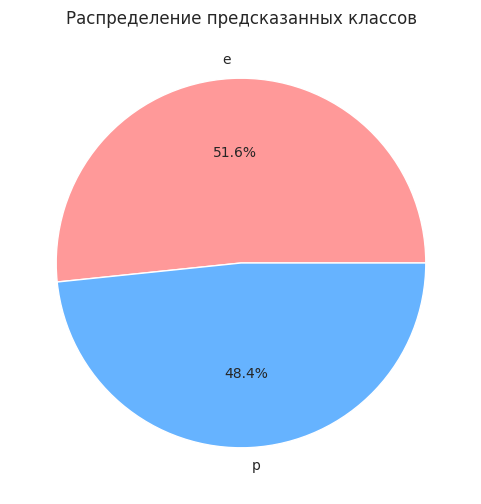

In [9]:

## 9.3. Круговая диаграмма предсказанных классов
# Круговая диаграмма (pie chart) визуализирует процентное соотношение предсказанных классов.
plt.figure(figsize=(6, 6))
plt.pie(np.bincount(y_pred), labels=class_var.values, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title("Распределение предсказанных классов")
plt.show()

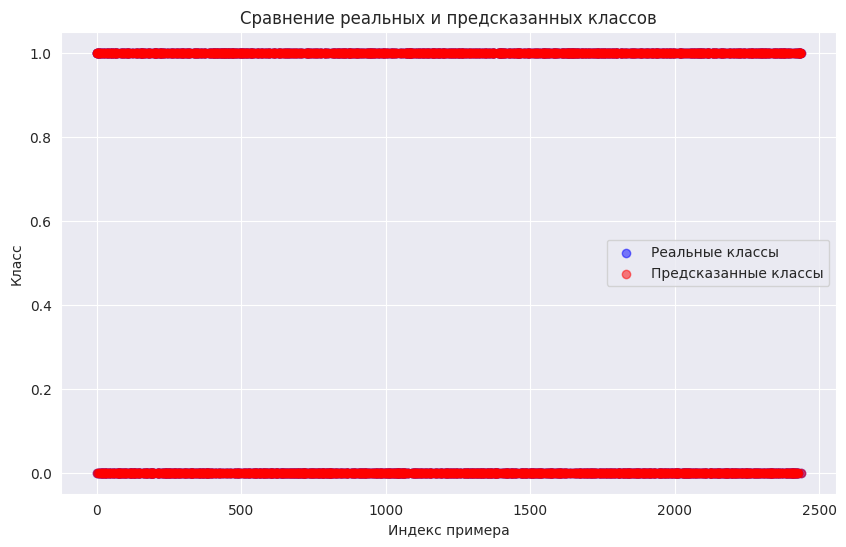

In [10]:

## 9.4. График сравнения реальных и предсказанных классов
# Строим scatter plot, где по оси X – индекс примера, а по оси Y – класс.
# Это позволяет наглядно сравнить истинные метки и предсказанные моделью.
y_test_num = y_test.cat.codes
y_pred_num = y_pred

plt.figure(figsize=(10, 6))
plt.scatter(range(len(y_test_num)), y_test_num, color='blue', label='Реальные классы', alpha=0.5)
plt.scatter(range(len(y_pred_num)), y_pred_num, color='red', label='Предсказанные классы', alpha=0.5)
plt.title("Сравнение реальных и предсказанных классов")
plt.xlabel("Индекс примера")
plt.ylabel("Класс")
plt.legend()
plt.show()
# Преобразуем истинные и предсказанные метки в числовой формат
y_test_num = y_test.cat.codes
y_pred_num = y_pred

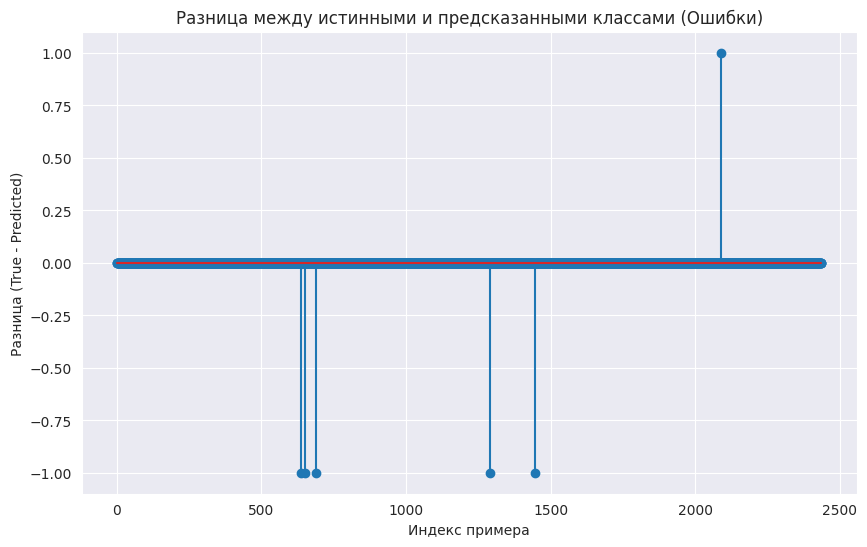

In [11]:

# Вычисляем разницу между истинными и предсказанными метками
errors = y_test_num - y_pred_num

# Строим stem plot, где по оси X – индекс примера, а по оси Y – разница (0 для правильных, ±1 для ошибок)
plt.figure(figsize=(10, 6))
plt.stem(range(len(errors)), errors)  # убрали use_line_collection
plt.title("Разница между истинными и предсказанными классами (Ошибки)")
plt.xlabel("Индекс примера")
plt.ylabel("Разница (True - Predicted)")
plt.show()

In [12]:

################################################################################
# Итоговый анализ и комментарии:
#
# 1. Загрузка и предобработка данных:
#    - Датасет "mushrooms.csv" загружается и все признаки приводятся к категориальному типу.
#    - Это позволяет работать с данными в их натуральном виде без необходимости сложного кодирования.
#
# 2. Разделение данных:
#    - Данные разбиваются на обучающую и тестовую выборки с сохранением пропорций классов (stratify=y).
#
# 3. Создание домена Orange3:
#    - Формируется Domain, включающий все категориальные признаки и целевую переменную.
#    - Это необходимо для корректного преобразования данных в формат Orange Table.
#
# 4. Преобразование категориальных данных:
#    - Категориальные значения преобразуются в числовые коды (cat.codes), что позволяет обучать модель CN2.
#
# 5. Обучение модели CN2:
#    - Модель CN2Learner обучается на преобразованных данных.
#    - CN2 – правило-ориентированный классификатор, который генерирует набор правил для классификации.
#
# 6. Оценка модели:
#    - Выводятся стандартные метрики (precision, recall, f1-score) и общая точность (accuracy).
#    - Полученные результаты (accuracy ≈ 0.9975, очень высокие метрики) свидетельствуют о качественном обучении модели.
#
# 7. Визуализация результатов:
#    - Матрица ошибок (heatmap) дает наглядное представление о количестве верных и ошибочных предсказаний.
#    - Гистограмма и круговая диаграмма показывают распределение предсказанных классов.
#    - График сравнения реальных и предсказанных классов позволяет увидеть расхождения между ними.
#
# 8. Рекомендации по дополнительным визуализациям:
#    - Несмотря на то, что уже построены несколько графиков (матрица ошибок, гистограмма, круговая диаграмма, scatter plot),
#      можно добавить дополнительные визуализации для более глубокого анализа:
#         • Визуализация набора правил, полученных алгоритмом CN2, если такая возможность поддерживается библиотекой.
#         • ROC-кривая или Precision-Recall кривая – однако для алгоритмов, выдающих дискретные предсказания, эти графики
#           могут быть менее информативны, так как отсутствуют вероятностные оценки.
#         • Бар-чарт для сравнения значений метрик (precision, recall, f1-score) для каждого класса.
#
# 9. Выводы:
#    - Модель CN2 продемонстрировала высокую точность классификации (accuracy ≈ 99.75%),
#      что указывает на отличное разделение классов в датасете грибов.
#    - Вычисленные метрики (precision, recall, f1-score) для обоих классов находятся на очень высоком уровне.
#    - Построенные графики (матрица ошибок, гистограмма, круговая диаграмма и scatter plot)
#      позволяют визуально оценить качество модели и распределение предсказанных классов.
#    - Дополнительная визуализация, например, набора правил или сравнительного бар-чарта метрик,
#      могла бы еще более явно продемонстрировать результаты работы модели.
#
# Данный код демонстрирует полный цикл работы с данными:
# - от загрузки и предобработки,
# - через создание домена и преобразование категориальных данных,
# - до обучения модели CN2 и визуальной оценки результатов.
################################################################################
